# ch222 — Area Under Curve

Area is the canonical meaning of the definite integral. But the concept extends: it applies to probability densities, signal energy, ROC curves in ML evaluation, and more.

This chapter builds intuition for **signed area** and connects integration to probability *(forward reference: Part VIII — Probability)*.

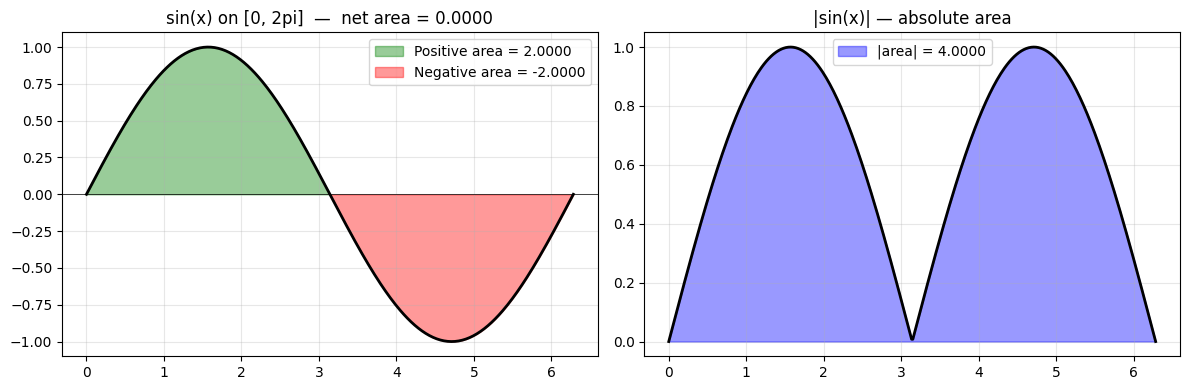

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Signed area: f(x) below x-axis contributes negatively
f = lambda x: np.sin(x)
x = np.linspace(0, 2*np.pi, 400)

# Full integral over [0, 2pi] of sin is 0 (symmetric)
total, _ = quad(f, 0, 2*np.pi)
pos_area, _ = quad(f, 0, np.pi)
neg_area, _ = quad(f, np.pi, 2*np.pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, np.sin(x), 'k', lw=2)
axes[0].fill_between(x, np.sin(x), where=(np.sin(x) >= 0), alpha=0.4, color='green', label=f'Positive area = {pos_area:.4f}')
axes[0].fill_between(x, np.sin(x), where=(np.sin(x) < 0),  alpha=0.4, color='red',   label=f'Negative area = {neg_area:.4f}')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title(f'sin(x) on [0, 2pi]  —  net area = {total:.4f}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Absolute area
abs_area, _ = quad(lambda x: abs(np.sin(x)), 0, 2*np.pi)
axes[1].plot(x, np.abs(np.sin(x)), 'k', lw=2)
axes[1].fill_between(x, np.abs(np.sin(x)), alpha=0.4, color='blue', label=f'|area| = {abs_area:.4f}')
axes[1].set_title('|sin(x)| — absolute area')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch222_signed.png', dpi=100); plt.show()


## Probability Densities and the CDF

A **probability density function (PDF)** must integrate to 1. The **cumulative distribution function (CDF)** is the running integral of the PDF. Every probability statement is an area calculation.

Total area under N(0,1) PDF: 1.00000000
P(-1 < X < 1) = 68.27%  (the 68-95-99.7 rule)


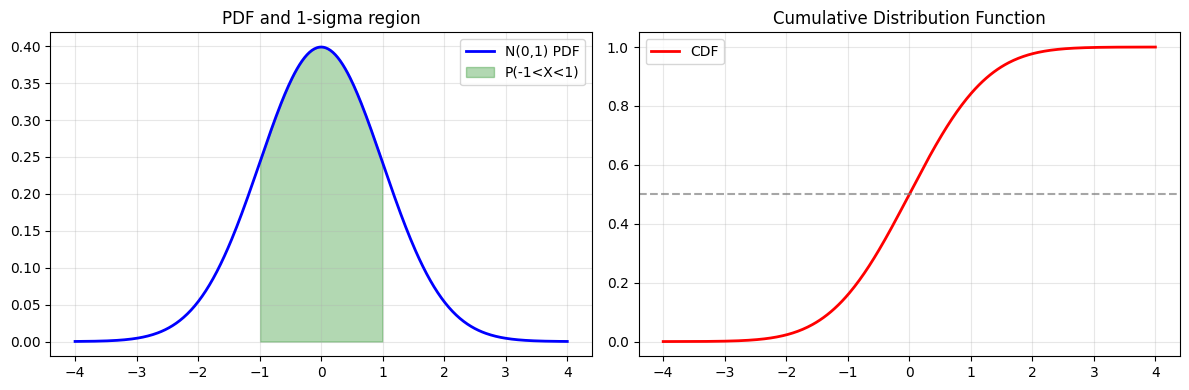

In [2]:
# Normal distribution: PDF and CDF
def normal_pdf(x, mu=0, sigma=1):
    return np.exp(-0.5*((x-mu)/sigma)**2) / (sigma * np.sqrt(2*np.pi))

x = np.linspace(-4, 4, 400)
pdf = normal_pdf(x)

# CDF via cumulative trapezoid
from scipy.integrate import cumulative_trapezoid
cdf = cumulative_trapezoid(pdf, x, initial=0)

# Verify total area = 1
total_area, _ = quad(lambda x: normal_pdf(x), -np.inf, np.inf)
print(f"Total area under N(0,1) PDF: {total_area:.8f}")

# P(-1 < X < 1) = 68.27% rule
area_1sigma, _ = quad(lambda x: normal_pdf(x), -1, 1)
print(f"P(-1 < X < 1) = {area_1sigma*100:.2f}%  (the 68-95-99.7 rule)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, pdf, 'b', lw=2, label='N(0,1) PDF')
axes[0].fill_between(x, pdf, where=(x >= -1) & (x <= 1), alpha=0.3, color='green', label='P(-1<X<1)')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_title('PDF and 1-sigma region')

axes[1].plot(x, cdf, 'r', lw=2, label='CDF')
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.7)
axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_title('Cumulative Distribution Function')
plt.tight_layout(); plt.savefig('ch222_pdf_cdf.png', dpi=100); plt.show()


## ROC Curve — Area as a Performance Metric

The AUC (Area Under the ROC Curve) is a single number summarising classifier performance. It is a definite integral. A perfect classifier has AUC=1; random guessing gives AUC=0.5.

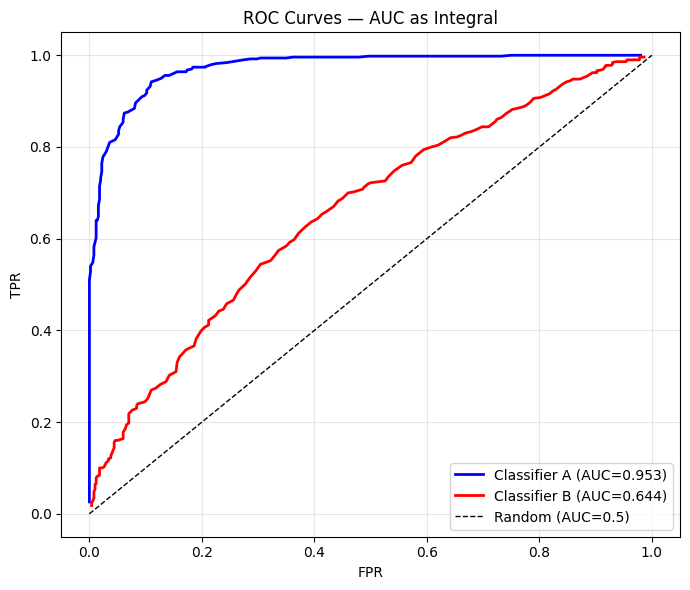

AUC A: 0.953, AUC B: 0.644


In [4]:
# Simulate ROC curves for two classifiers
np.random.seed(42)
n = 500

# Classifier A: good separation
scores_pos_A = np.random.normal(0.7, 0.15, n)
scores_neg_A = np.random.normal(0.3, 0.15, n)

# Classifier B: poor separation
scores_pos_B = np.random.normal(0.55, 0.2, n)
scores_neg_B = np.random.normal(0.45, 0.2, n)

def compute_roc(pos_scores, neg_scores, n_thresh=200):
    thresholds = np.linspace(0, 1, n_thresh)
    tpr_list, fpr_list = [], []
    for t in thresholds:
        tp = np.sum(pos_scores >= t) / n
        fp = np.sum(neg_scores >= t) / n
        tpr_list.append(tp); fpr_list.append(fp)
    return np.array(fpr_list), np.array(tpr_list)

fpr_A, tpr_A = compute_roc(scores_pos_A, scores_neg_A)
fpr_B, tpr_B = compute_roc(scores_pos_B, scores_neg_B)

# AUC via trapezoid rule (area under ROC)
auc_A = np.trapezoid(tpr_A[::-1], fpr_A[::-1])
auc_B = np.trapezoid(tpr_B[::-1], fpr_B[::-1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_A, tpr_A, 'b', lw=2, label=f'Classifier A (AUC={auc_A:.3f})')
plt.plot(fpr_B, tpr_B, 'r', lw=2, label=f'Classifier B (AUC={auc_B:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves — AUC as Integral')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch222_roc.png', dpi=100); plt.show()
print(f"AUC A: {auc_A:.3f}, AUC B: {auc_B:.3f}")


## Summary

| Application | What is being integrated |
|---|---|
| Geometry | Height of a curve → area |
| Probability | PDF → probability of interval |
| CDF | Running sum of probabilities |
| ROC/AUC | TPR vs FPR → classifier performance |
| Signal processing | Power spectral density → total energy |

**Forward reference:** ch223 — Numerical Integration implements algorithms that compute these integrals when no closed form exists.